In [1]:
import pandas as pd

In [2]:
# 1. 데이터 불러오기
customers = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\archive\olist_customers_dataset.csv")
items = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\archive\olist_order_items_dataset.csv")
orders = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\archive\olist_orders_dataset.csv")

In [3]:
# 2. 데이터 병합
base = customers.merge(orders, on="customer_id", how="left")
base = base.merge(items, on="order_id", how="left")

In [4]:
# 3. 배송 완료 주문만 사용
base_delivered = base[base["order_status"] == "delivered"].copy()

In [5]:
# 4. 날짜 변환
base_delivered["order_purchase_timestamp"] = pd.to_datetime(
    base_delivered["order_purchase_timestamp"])

In [6]:
# 5. 분석 기간 제한: 2018년 8월까지
base_til1808 = base_delivered[
    base_delivered["order_purchase_timestamp"] < "2018-09-01"].copy()

In [7]:
# 6. 고객 단위 요약 테이블 생성
customer_order = (
    base_til1808
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique"),
        first_order=("order_purchase_timestamp", "min"),
        last_order=("order_purchase_timestamp", "max")
    ).reset_index())

In [8]:
# 7. 재구매 여부
customer_summary = customer_order.copy()
customer_summary["is_repeat"] = customer_summary["order_count"] >= 2

In [9]:
# 8. 활동 기간
customer_summary["duration"] = (
    customer_summary["last_order"] - customer_summary["first_order"]).dt.days

In [10]:
# 9. 최근성
reference_date = customer_summary["last_order"].max()

customer_summary["recency"] = (
    reference_date - customer_summary["last_order"]).dt.days

In [11]:
# 10. 월 단위 컬럼
customer_summary["first_order_month"] = customer_summary["first_order"].dt.to_period("M")
customer_summary["last_order_month"] = customer_summary["last_order"].dt.to_period("M")

In [12]:
# 11. 기본 재구매율
repeat_rate = customer_summary["is_repeat"].mean()
repeat_rate

np.float64(0.03000278497825575)

In [13]:
# 12. 재구매 / 비재구매 고객 비교
customer_summary.groupby("is_repeat")[["order_count", "duration", "recency"]].mean()

,order_count,duration,recency
is_repeat,,,
False,1.000000,0.000000,237.487616
True,2.113888,87.792931,219.294538


In [14]:
# 13. 월별 신규 고객 수
repeat_table = (customer_summary
    .groupby(["first_order_month", "is_repeat"])
    .size()
    .reset_index(name="customer_count"))

repeat_table["first_order_month"] = repeat_table["first_order_month"].dt.to_timestamp()

repeat_table.head()

,first_order_month,is_repeat,customer_count
0,2016-09-01,False,1
1,2016-10-01,False,250
2,2016-10-01,True,12
3,2016-12-01,True,1
4,2017-01-01,False,665


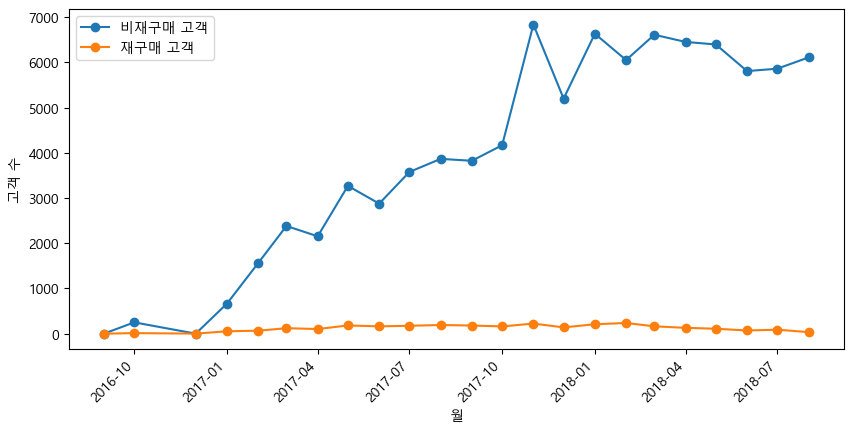

In [15]:
# 14. 신규고객 그래프
import matplotlib.pyplot as plt                  
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False      # 마이너스 깨짐 방지

plot_table = repeat_table.pivot(
    index="first_order_month",
    columns="is_repeat",
    values="customer_count"
).fillna(0)

plot_table.columns = ["non_repeat", "repeat"]

plot_table.plot(figsize=(10, 5), marker="o")

plt.xlabel("월")
plt.ylabel("고객 수")
plt.xticks(rotation=45)
plt.legend(["비재구매 고객", "재구매 고객"])
plt.show()

In [16]:
# 15. 주문 단위 코호트 테이블 생성
orders_cohort = base_til1808[
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
].drop_duplicates()

orders_cohort["order_month"] = (
    orders_cohort["order_purchase_timestamp"].dt.to_period("M"))

first_order = (
    orders_cohort
    .groupby("customer_unique_id")["order_month"]
    .min()
    .reset_index())

first_order.columns = ["customer_unique_id", "cohort_month"]

orders_cohort = orders_cohort.merge(
    first_order,
    on="customer_unique_id",
    how="left")

In [17]:
# 16. 첫 구매 후 몇 개월 뒤 구매인지
orders_cohort["cohort_index"] = (
    (orders_cohort["order_month"].dt.year - orders_cohort["cohort_month"].dt.year) * 12
    + (orders_cohort["order_month"].dt.month - orders_cohort["cohort_month"].dt.month))

In [18]:
# 17. 코호트 고객 수 테이블
cohort_count = (
    orders_cohort
    .groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index())

cohort_table = cohort_count.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id")

cohort_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [19]:
# 18. 코호트 유지율
cohort_rate = cohort_table.div(cohort_table[0], axis=0)
cohort_rate

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN
2017-03,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN
2017-04,1.0,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546,0.003103,0.003103,0.001773,0.002660,0.000887,0.000443,0.000443,0.000887,0.000887,0.001330,NaN,NaN,NaN
2017-05,1.0,0.004636,0.004636,0.002898,0.002898,0.003187,0.004057,0.001449,0.002608,0.002608,0.002608,0.003477,0.002318,0.000290,0.001739,0.002028,NaN,NaN,NaN,NaN
2017-06,1.0,0.004939,0.003951,0.004281,0.002963,0.003951,0.003622,0.002305,0.001317,0.001976,0.002963,0.003622,0.001646,0.001646,0.002305,NaN,NaN,NaN,NaN,NaN


In [20]:
# 19. cohort_month를 그래프용 날짜로 변환
cohort_rate_plot = cohort_rate.copy()
cohort_rate_plot.index = cohort_rate_plot.index.to_timestamp()

In [21]:
# 20 첫 구매월 이후 1~3개월 유지율만 보기
retention_1_3 = cohort_rate_plot[[1, 2, 3]]

retention_1_3.tail()

cohort_index,1,2,3
cohort_month,,,
2018-04-01,0.005925,0.003039,0.002431
2018-05-01,0.005226,0.002613,0.001844
2018-06-01,0.004253,0.002722,NaN
2018-07-01,0.005211,NaN,NaN
2018-08-01,NaN,NaN,NaN


In [22]:
# 21 기간 늘리기
retention_recent = retention_1_3.tail(8)
retention_recent

cohort_index,1,2,3
cohort_month,,,
2018-01-01,0.003362,0.003654,0.002923
2018-02-01,0.003499,0.003976,0.003022
2018-03-01,0.003986,0.002952,0.002952
2018-04-01,0.005925,0.003039,0.002431
2018-05-01,0.005226,0.002613,0.001844
2018-06-01,0.004253,0.002722,NaN
2018-07-01,0.005211,NaN,NaN
2018-08-01,NaN,NaN,NaN


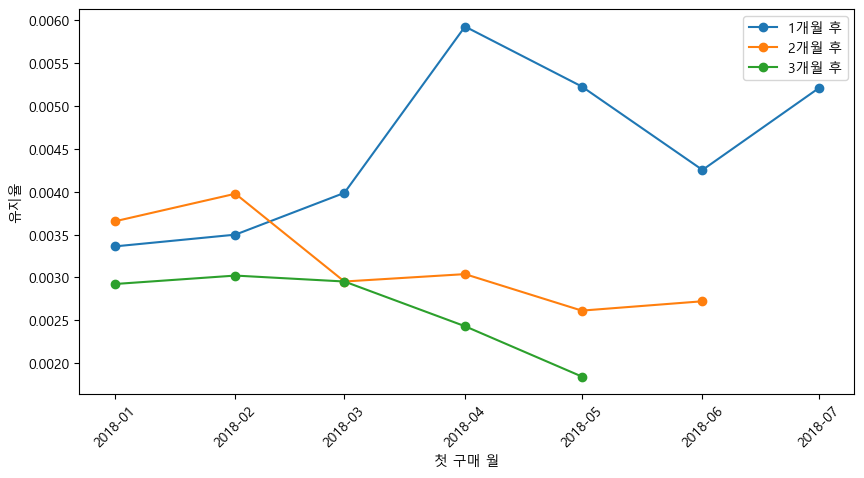

In [23]:
# 22 코호트 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for col in retention_recent.columns:
    plt.plot(
        retention_recent.index,
        retention_recent[col],
        marker="o",
        label=f"{col}개월 후"
    )

plt.xlabel("첫 구매 월")
plt.ylabel("유지율")
plt.xticks(rotation=45)
plt.legend()
plt.show()